# Text2Cypher: Neo4j 그래프 데이터베이스 질의 에이전트

이 튜토리얼에서는 **자연어 질문을 Neo4j Cypher 쿼리로 변환하고 실행하는 파이프라인**을 LangGraph의 `StateGraph`를 활용하여 구축하는 방법을 소개합니다.

Text2Cypher는 사용자의 자연어 질문을 그래프 데이터베이스 질의 언어인 Cypher로 변환하고, 이를 실행하여 결과를 자연어로 요약하는 방식입니다. 이 과정에서 쿼리 검증과 오류 재시도 로직을 포함하여 안정적인 파이프라인을 구성합니다.

![text2cypher-flow](./assets/text2cypher-flow.png)

---

**주요 내용**

- **Neo4j 데이터베이스 설정**: AuraDB 또는 Docker를 활용한 Neo4j 연결 및 Movies 샘플 데이터셋 로드
- **Text2Cypher 파이프라인 구축**: 자연어 → Cypher 쿼리 생성 → 검증 → 실행 → 자연어 응답
- **조건부 재시도 로직**: 쿼리 실행 오류 시 자동으로 쿼리를 재생성하는 재시도 메커니즘
- **그래프 시각화 및 실행**: 정의된 StateGraph를 시각화하고 다양한 질문으로 실행

---

**참고 자료**

- [LangGraph 공식 문서](https://langchain-ai.github.io/langgraph/)
- [Neo4j Cypher Manual](https://neo4j.com/docs/cypher-manual/current/)
- [langchain-neo4j 패키지](https://python.langchain.com/docs/integrations/providers/neo4j/)
- [Neo4j GraphRAG - Text2Cypher](https://neo4j.com/labs/genai-ecosystem/graphrag-python/)

## 환경 설정

Text2Cypher 파이프라인을 구현하기 위해 필요한 환경을 설정합니다. API 키를 환경변수로 관리하고, LangSmith를 통해 실행 과정을 추적할 수 있도록 설정합니다.

아래 코드는 `.env` 파일에서 API 키를 로드하고 LangSmith 추적을 활성화합니다.

In [1]:
# API 키를 환경변수로 관리하기 위한 설정 파일
from dotenv import load_dotenv

# API 키 정보 로드
load_dotenv(override=True)

True

In [2]:
# LangSmith 추적을 설정합니다.
from langchain_teddynote import logging

# 프로젝트 이름을 입력합니다.
logging.langsmith("LangGraph-GraphRAG")

LangSmith 추적을 시작합니다.
[프로젝트명]
LangGraph-GraphRAG


## Neo4j 데이터베이스 설정

이 튜토리얼에서는 Neo4j 그래프 데이터베이스를 사용합니다. Neo4j에 연결하는 방법은 두 가지가 있습니다.

**방법 1: Neo4j AuraDB (클라우드)**
- [Neo4j AuraDB](https://neo4j.com/cloud/platform/aura-graph-database/)에서 무료 인스턴스를 생성합니다.
- 생성 후 제공되는 `NEO4J_URI`, `NEO4J_USERNAME`, `NEO4J_PASSWORD`를 `.env` 파일에 추가합니다.
- AuraDB는 APOC 플러그인이 기본 제공됩니다.

**방법 2: Docker (로컬)**
```bash
docker run -d --name neo4j \
  -p 7474:7474 -p 7687:7687 \
  -e NEO4J_AUTH=neo4j/your_password \
  -e NEO4J_PLUGINS='["apoc"]' \
  neo4j:latest
```

`Neo4jGraph`의 스키마 조회 기능이 APOC 플러그인(`apoc.meta.data()`)을 사용하므로, Docker 환경에서는 반드시 `NEO4J_PLUGINS` 설정을 포함해야 합니다.

`.env` 파일에 다음 환경변수를 설정합니다:
```
NEO4J_URI=bolt://localhost:7687
NEO4J_USERNAME=neo4j
NEO4J_PASSWORD=your_password
```

### Neo4j 연결

`langchain_neo4j`에서 제공하는 `Neo4jGraph`를 사용하여 Neo4j 데이터베이스에 연결합니다. 이 객체는 Cypher 쿼리 실행과 스키마 조회 기능을 제공합니다.

아래 코드는 환경변수에서 연결 정보를 읽어 Neo4j에 연결합니다.

In [3]:
import os
from langchain_neo4j import Neo4jGraph

# Neo4j 데이터베이스 연결
graph_db = Neo4jGraph(
    url=os.environ["NEO4J_URI"],
    username=os.environ["NEO4J_USERNAME"],
    password=os.environ["NEO4J_PASSWORD"],
)

print("Neo4j 데이터베이스에 연결되었습니다.")

Neo4j 데이터베이스에 연결되었습니다.


## Movies 샘플 데이터셋 로드

Neo4j에서 제공하는 Movies 샘플 데이터셋을 로드합니다. 이 데이터셋에는 영화, 배우, 감독 간의 관계 정보가 포함되어 있습니다.

아래 코드는 Movies 데이터셋을 Cypher 스크립트로 Neo4j에 로드합니다.

In [4]:
# Movies 샘플 데이터셋 로드 Cypher 스크립트
movies_cypher = """
CREATE (TheMatrix:Movie {title:'The Matrix', released:1999, tagline:'Welcome to the Real World'})
CREATE (Keanu:Person {name:'Keanu Reeves', born:1964})
CREATE (Carrie:Person {name:'Carrie-Anne Moss', born:1967})
CREATE (Laurence:Person {name:'Laurence Fishburne', born:1961})
CREATE (Hugo:Person {name:'Hugo Weaving', born:1960})
CREATE (LillyW:Person {name:'Lilly Wachowski', born:1967})
CREATE (LanaW:Person {name:'Lana Wachowski', born:1965})
CREATE (JoelS:Person {name:'Joel Silver', born:1952})

CREATE (TheMatrixReloaded:Movie {title:'The Matrix Reloaded', released:2003, tagline:'Free your mind'})
CREATE (TheMatrixRevolutions:Movie {title:'The Matrix Revolutions', released:2003, tagline:'Everything that has a beginning has an end'})

CREATE (TomH:Person {name:'Tom Hanks', born:1956})
CREATE (ForrestGump:Movie {title:'Forrest Gump', released:1994, tagline:'Life is like a box of chocolates'})
CREATE (RobertZ:Person {name:'Robert Zemeckis', born:1951})
CREATE (CastAway:Movie {title:'Cast Away', released:2000, tagline:'At the edge of the world, his journey begins'})

CREATE (TopGun:Movie {title:'Top Gun', released:1986, tagline:'I feel the need, the need for speed.'})
CREATE (TomC:Person {name:'Tom Cruise', born:1962})
CREATE (TonyS:Person {name:'Tony Scott', born:1944})
CREATE (JerryMaguire:Movie {title:'Jerry Maguire', released:1996, tagline:'The rest of his life begins now.'})
CREATE (CameronC:Person {name:'Cameron Crowe', born:1957})

CREATE (AFewGoodMen:Movie {title:'A Few Good Men', released:1992, tagline:"You can't handle the truth!"})
CREATE (JackN:Person {name:'Jack Nicholson', born:1937})
CREATE (RobR:Person {name:'Rob Reiner', born:1947})

CREATE
  (Keanu)-[:ACTED_IN {roles:['Neo']}]->(TheMatrix),
  (Carrie)-[:ACTED_IN {roles:['Trinity']}]->(TheMatrix),
  (Laurence)-[:ACTED_IN {roles:['Morpheus']}]->(TheMatrix),
  (Hugo)-[:ACTED_IN {roles:['Agent Smith']}]->(TheMatrix),
  (LillyW)-[:DIRECTED]->(TheMatrix),
  (LanaW)-[:DIRECTED]->(TheMatrix),
  (JoelS)-[:PRODUCED]->(TheMatrix),

  (Keanu)-[:ACTED_IN {roles:['Neo']}]->(TheMatrixReloaded),
  (Carrie)-[:ACTED_IN {roles:['Trinity']}]->(TheMatrixReloaded),
  (Laurence)-[:ACTED_IN {roles:['Morpheus']}]->(TheMatrixReloaded),
  (Hugo)-[:ACTED_IN {roles:['Agent Smith']}]->(TheMatrixReloaded),
  (LillyW)-[:DIRECTED]->(TheMatrixReloaded),
  (LanaW)-[:DIRECTED]->(TheMatrixReloaded),

  (Keanu)-[:ACTED_IN {roles:['Neo']}]->(TheMatrixRevolutions),
  (Carrie)-[:ACTED_IN {roles:['Trinity']}]->(TheMatrixRevolutions),
  (Laurence)-[:ACTED_IN {roles:['Morpheus']}]->(TheMatrixRevolutions),
  (Hugo)-[:ACTED_IN {roles:['Agent Smith']}]->(TheMatrixRevolutions),
  (LillyW)-[:DIRECTED]->(TheMatrixRevolutions),
  (LanaW)-[:DIRECTED]->(TheMatrixRevolutions),

  (TomH)-[:ACTED_IN {roles:['Forrest Gump']}]->(ForrestGump),
  (RobertZ)-[:DIRECTED]->(ForrestGump),

  (TomH)-[:ACTED_IN {roles:['Chuck Noland']}]->(CastAway),
  (RobertZ)-[:DIRECTED]->(CastAway),

  (TomC)-[:ACTED_IN {roles:['Maverick']}]->(TopGun),
  (TonyS)-[:DIRECTED]->(TopGun),

  (TomC)-[:ACTED_IN {roles:['Jerry Maguire']}]->(JerryMaguire),
  (CameronC)-[:DIRECTED]->(JerryMaguire),

  (TomC)-[:ACTED_IN {roles:['Lt. Daniel Kaffee']}]->(AFewGoodMen),
  (JackN)-[:ACTED_IN {roles:['Col. Nathan R. Jessep']}]->(AFewGoodMen),
  (RobR)-[:DIRECTED]->(AFewGoodMen)
"""

# 기존 데이터 삭제 후 새로 로드
graph_db.query("MATCH (n) DETACH DELETE n")
graph_db.query(movies_cypher)
print("Movies 샘플 데이터셋이 로드되었습니다.")

Movies 샘플 데이터셋이 로드되었습니다.


### 데이터셋 확인

로드된 데이터셋의 노드와 관계 통계를 확인합니다.

아래 코드는 데이터베이스의 노드 수, 관계 수를 조회하고 샘플 데이터를 확인합니다.

In [5]:
# 노드 수 조회
node_count = graph_db.query("MATCH (n) RETURN count(n) AS count")[0]["count"]
print(f"전체 노드 수: {node_count}")

# 관계 수 조회
rel_count = graph_db.query("MATCH ()-[r]->() RETURN count(r) AS count")[0]["count"]
print(f"전체 관계 수: {rel_count}")

# 영화 목록 샘플 조회
print("\n영화 목록 (상위 5개):")
movies = graph_db.query("MATCH (m:Movie) RETURN m.title AS title, m.released AS released ORDER BY m.released DESC LIMIT 5")
for m in movies:
    print(f"  - {m['title']} ({m['released']})")

전체 노드 수: 22
전체 관계 수: 30

영화 목록 (상위 5개):
  - The Matrix Reloaded (2003)
  - The Matrix Revolutions (2003)
  - Cast Away (2000)
  - The Matrix (1999)
  - Jerry Maguire (1996)


### 그래프 스키마 확인

`Neo4jGraph` 객체의 `schema` 속성을 통해 데이터베이스의 스키마를 확인할 수 있습니다. 스키마에는 노드 레이블, 관계 유형, 속성 정보가 포함됩니다. 이 정보는 LLM이 올바른 Cypher 쿼리를 생성하는 데 핵심적인 역할을 합니다.

아래 코드는 그래프 스키마를 새로고침하고 출력합니다.

In [6]:
# 스키마 새로고침
graph_db.refresh_schema()

# 스키마 출력
print(graph_db.schema)

Node properties:
Movie {title: STRING, tagline: STRING, released: INTEGER}
Person {born: INTEGER, name: STRING}
Relationship properties:
ACTED_IN {roles: LIST}
The relationships:
(:Person)-[:ACTED_IN]->(:Movie)
(:Person)-[:DIRECTED]->(:Movie)
(:Person)-[:PRODUCED]->(:Movie)


## LLM 설정

Cypher 쿼리 생성과 자연어 응답 생성에 사용할 LLM을 초기화합니다.

아래 코드는 `init_chat_model`을 사용하여 LLM을 설정합니다.

In [7]:
from langchain.chat_models import init_chat_model

# OpenAI 키를 사용하는 경우 gpt-4.1-mini, gpt-5.2 등의 모델로 변경하세요.
llm = init_chat_model("claude-sonnet-4-5", temperature=0)

## 상태(State) 정의

Text2Cypher 파이프라인에서 사용할 상태를 정의합니다. 각 노드는 이 상태를 읽고 업데이트하며 다음 노드로 전달합니다.

- `question`: 사용자가 입력한 자연어 질문
- `schema`: 그래프 데이터베이스 스키마
- `cypher_query`: LLM이 생성한 Cypher 쿼리
- `cypher_result`: Cypher 쿼리 실행 결과
- `answer`: 최종 자연어 응답
- `error`: 오류 메시지 (없으면 빈 문자열)
- `retry_count`: 재시도 횟수

아래 코드는 `Text2CypherState` TypedDict를 정의합니다.

In [8]:
from typing_extensions import TypedDict, Annotated


# Text2Cypher 파이프라인의 상태 정의
class Text2CypherState(TypedDict):
    # 사용자의 자연어 질문
    question: Annotated[str, "User question"]
    # 그래프 데이터베이스 스키마
    schema: Annotated[str, "Graph database schema"]
    # 생성된 Cypher 쿼리
    cypher_query: Annotated[str, "Generated Cypher query"]
    # Cypher 쿼리 실행 결과
    cypher_result: Annotated[str, "Cypher query result"]
    # 최종 자연어 응답
    answer: Annotated[str, "Final answer"]
    # 오류 메시지
    error: Annotated[str, "Error message"]
    # 재시도 횟수
    retry_count: Annotated[int, "Retry count"]

## 노드(Node) 정의

Text2Cypher 파이프라인은 다음 5개의 노드로 구성됩니다.

1. `get_schema`: 데이터베이스 스키마를 조회
2. `generate_cypher`: 자연어 질문과 스키마를 기반으로 Cypher 쿼리 생성
3. `validate_cypher`: 생성된 Cypher 쿼리의 기본적인 유효성 검사
4. `execute_cypher`: Cypher 쿼리를 실행하고 결과 또는 오류를 반환
5. `generate_answer`: 쿼리 결과를 기반으로 자연어 응답 생성

아래 코드는 각 노드 함수를 정의합니다.

In [9]:
def get_schema(state: Text2CypherState):
    """Retrieve the graph database schema."""
    print("==== [GET SCHEMA] ====")
    # 스키마 새로고침
    graph_db.refresh_schema()
    return {"schema": graph_db.schema}

In [10]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# Cypher 쿼리 생성을 위한 시스템 프롬프트
cypher_generation_system = """You are an expert Neo4j developer. Given a user question and a graph database schema, generate a syntactically correct Cypher query to answer the question.

Instructions:
- Use only the node labels, relationship types, and properties mentioned in the schema.
- Do NOT use any node labels, relationship types, or properties that are not in the schema.
- For string matching, prefer case-insensitive matching with `toLower()` or `CONTAINS`.
- Always use aliases for nodes and relationships (e.g., `MATCH (m:Movie)` not `MATCH (:Movie)`).
- Return ONLY the Cypher query without any explanation, backticks, or markdown formatting.
- Do NOT include any DML statements (CREATE, DELETE, SET, MERGE, etc.).

Schema:
{schema}"""

# Cypher 쿼리 생성 프롬프트
cypher_generation_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", cypher_generation_system),
        ("human", "{question}"),
    ]
)

# Cypher 쿼리 생성 체인
cypher_chain = cypher_generation_prompt | llm | StrOutputParser()


def generate_cypher(state: Text2CypherState):
    """Generate a Cypher query from the user question and schema."""
    print("==== [GENERATE CYPHER] ====")
    question = state["question"]
    schema = state["schema"]

    # Cypher 쿼리 생성
    cypher_query = cypher_chain.invoke({"question": question, "schema": schema})

    # 쿼리 앞뒤 공백 및 백틱 제거
    cypher_query = cypher_query.strip().strip("`").strip()
    if cypher_query.startswith("cypher"):
        cypher_query = cypher_query[6:].strip()

    print(f"생성된 Cypher 쿼리: {cypher_query}")
    return {"cypher_query": cypher_query, "error": ""}

In [11]:
# Cypher 쿼리에서 허용하지 않는 키워드 목록
DISALLOWED_KEYWORDS = ["CREATE", "DELETE", "SET", "MERGE", "DROP", "REMOVE", "DETACH"]


def validate_cypher(state: Text2CypherState):
    """Validate the generated Cypher query for basic safety checks."""
    print("==== [VALIDATE CYPHER] ====")
    cypher_query = state["cypher_query"]

    # DML 키워드 포함 여부 확인
    query_upper = cypher_query.upper()
    for keyword in DISALLOWED_KEYWORDS:
        if keyword in query_upper:
            error_msg = f"쿼리에 허용되지 않는 키워드가 포함되어 있습니다: {keyword}"
            print(f"==== [VALIDATION FAILED] {error_msg} ====")
            return {"error": error_msg}

    # 빈 쿼리 확인
    if not cypher_query.strip():
        error_msg = "빈 쿼리가 생성되었습니다."
        print(f"==== [VALIDATION FAILED] {error_msg} ====")
        return {"error": error_msg}

    print("==== [VALIDATION PASSED] ====")
    return {"error": ""}

In [12]:
# 최대 재시도 횟수
MAX_RETRIES = 3


def execute_cypher(state: Text2CypherState):
    """Execute the Cypher query against the Neo4j database."""
    print("==== [EXECUTE CYPHER] ====")
    cypher_query = state["cypher_query"]
    retry_count = state.get("retry_count", 0)

    # 유효성 검사에서 오류가 있는 경우 실행하지 않음
    if state.get("error"):
        return {"retry_count": retry_count + 1}

    try:
        # Cypher 쿼리 실행
        result = graph_db.query(cypher_query)
        result_str = str(result)

        # 결과가 비어있는 경우
        if not result:
            result_str = "쿼리가 실행되었지만 결과가 없습니다."

        print(f"쿼리 결과: {result_str[:200]}")
        return {"cypher_result": result_str, "error": ""}

    except Exception as e:
        error_msg = f"쿼리 실행 오류: {str(e)}"
        print(f"==== [EXECUTION FAILED] {error_msg} ====")
        return {"error": error_msg, "retry_count": retry_count + 1}

In [13]:
# 자연어 응답 생성을 위한 프롬프트
answer_generation_system = """You are a helpful assistant that generates natural language answers based on Neo4j Cypher query results.

Given the user's question, the Cypher query that was executed, and the query result, provide a clear and concise answer in Korean.

If the query result is empty or indicates no data, let the user know politely.
If there was an error, explain what went wrong in simple terms.

Question: {question}
Cypher Query: {cypher_query}
Query Result: {cypher_result}"""

answer_generation_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", answer_generation_system),
        ("human", "위 결과를 바탕으로 질문에 답변해 주세요."),
    ]
)

# 응답 생성 체인
answer_chain = answer_generation_prompt | llm | StrOutputParser()


def generate_answer(state: Text2CypherState):
    """Generate a natural language answer from the query result."""
    print("==== [GENERATE ANSWER] ====")
    question = state["question"]
    cypher_query = state["cypher_query"]
    cypher_result = state.get("cypher_result", "")
    error = state.get("error", "")

    # 오류가 있는 경우 오류 메시지를 결과로 사용
    if error:
        cypher_result = f"오류 발생: {error}"

    # 자연어 응답 생성
    answer = answer_chain.invoke({
        "question": question,
        "cypher_query": cypher_query,
        "cypher_result": cypher_result,
    })

    return {"answer": answer}

## 조건부 엣지 정의

`should_retry` 함수는 `execute_cypher` 노드의 실행 결과에 따라 다음 경로를 결정합니다.

- **오류가 없는 경우**: `generate_answer`로 이동하여 최종 응답을 생성합니다.
- **오류가 있고 재시도 가능한 경우**: `generate_cypher`로 돌아가 쿼리를 다시 생성합니다.
- **재시도 횟수를 초과한 경우**: `generate_answer`로 이동하여 오류 메시지를 포함한 응답을 생성합니다.

아래 코드는 `should_retry` 라우팅 함수를 정의합니다.

In [14]:
from langgraph.graph import END


def should_retry(state: Text2CypherState):
    """Determine whether to retry query generation or proceed to answer generation."""
    error = state.get("error", "")
    retry_count = state.get("retry_count", 0)

    if not error:
        # 오류 없음 → 응답 생성
        print("==== [DECISION: SUCCESS → GENERATE ANSWER] ====")
        return "generate_answer"
    elif retry_count < MAX_RETRIES:
        # 재시도 가능 → 쿼리 재생성
        print(f"==== [DECISION: RETRY ({retry_count}/{MAX_RETRIES})] ====")
        return "generate_cypher"
    else:
        # 재시도 초과 → 오류 포함 응답 생성
        print(f"==== [DECISION: MAX RETRIES EXCEEDED ({retry_count}/{MAX_RETRIES})] ====")
        return "generate_answer" 

## 그래프 정의

이전에 정의한 노드와 엣지를 조합하여 `StateGraph`를 생성합니다. 전체 흐름은 다음과 같습니다:

1. `START` → `get_schema`: 데이터베이스 스키마 조회
2. `get_schema` → `generate_cypher`: Cypher 쿼리 생성
3. `generate_cypher` → `validate_cypher`: 쿼리 유효성 검사
4. `validate_cypher` → `execute_cypher`: 쿼리 실행
5. `execute_cypher` → 조건부 분기:
   - 성공 → `generate_answer` → `END`
   - 오류 + 재시도 가능 → `generate_cypher` (루프)
   - 재시도 초과 → `generate_answer` → `END`

아래 코드는 StateGraph를 생성하고 노드와 엣지를 연결합니다.

In [15]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

# StateGraph 초기화
workflow = StateGraph(Text2CypherState)

# 노드 추가
workflow.add_node("get_schema", get_schema)
workflow.add_node("generate_cypher", generate_cypher)
workflow.add_node("validate_cypher", validate_cypher)
workflow.add_node("execute_cypher", execute_cypher)
workflow.add_node("generate_answer", generate_answer)

# 엣지 정의
workflow.add_edge(START, "get_schema")
workflow.add_edge("get_schema", "generate_cypher")
workflow.add_edge("generate_cypher", "validate_cypher")
workflow.add_edge("validate_cypher", "execute_cypher")

# 조건부 엣지: execute_cypher 이후 분기
workflow.add_conditional_edges(
    "execute_cypher",
    should_retry,
    {
        "generate_answer": "generate_answer",
        "generate_cypher": "generate_cypher",
    },
)

workflow.add_edge("generate_answer", END)

# 그래프 컴파일
app = workflow.compile(checkpointer=MemorySaver())

## 그래프 시각화

그래프를 시각화하여 노드 간의 연결 관계를 확인합니다.

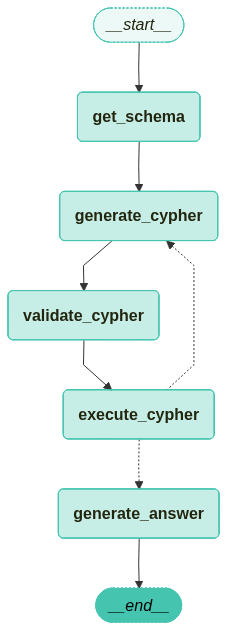

In [16]:
from langchain_teddynote.graphs import visualize_graph

visualize_graph(app, xray=True)

## 그래프 실행

생성한 그래프를 실행하여 자연어 질문에 대한 응답을 확인합니다. `run_text2cypher` 헬퍼 함수를 정의하여 반복 실행을 편리하게 합니다.

아래 코드는 실행 헬퍼 함수를 정의합니다.

In [17]:
from langchain_core.runnables import RunnableConfig
from langchain_teddynote.messages import invoke_graph, random_uuid


def run_text2cypher(question: str):
    """Run the Text2Cypher pipeline with a given question."""
    # config 설정
    config = RunnableConfig(
        recursion_limit=20,
        configurable={"thread_id": random_uuid()},
    )

    # 입력 정의
    inputs = {
        "question": question,
        "retry_count": 0,
    }

    # 그래프 실행
    invoke_graph(
        app,
        inputs,
        config,
        node_names=["get_schema", "generate_cypher", "validate_cypher", "execute_cypher", "generate_answer"],
    )

    # 최종 상태에서 응답 추출
    output = app.get_state(config).values
    return output

### 예시 1: 배우 출연작 조회

Keanu Reeves가 출연한 영화 목록을 조회합니다.

In [18]:
output = run_text2cypher("Keanu Reeves가 출연한 영화는 무엇인가요?")
print("\n최종 응답:")
print(output.get("answer", "응답 없음"))

==== [GET SCHEMA] ====

🔄 Node: get_schema 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
schema:
Node properties:
Movie {title: STRING, tagline: STRING, released: INTEGER}
Person {born: INTEGER, name: STRING}
Relationship properties:
ACTED_IN {roles: LIST}
The relationships:
(:Person)-[:ACTED_IN]->(:Movie)
(:Person)-[:DIRECTED]->(:Movie)
(:Person)-[:PRODUCED]->(:Movie)
==== [GENERATE CYPHER] ====
생성된 Cypher 쿼리: MATCH (p:Person)-[:ACTED_IN]->(m:Movie)
WHERE toLower(p.name) CONTAINS toLower('Keanu Reeves')
RETURN m.title

🔄 Node: generate_cypher 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
cypher_query:
MATCH (p:Person)-[:ACTED_IN]->(m:Movie)
WHERE toLower(p.name) CONTAINS toLower('Keanu Reeves')
RETURN m.title
error:

==== [VALIDATE CYPHER] ====
==== [VALIDATION PASSED] ====

🔄 Node: validate_cypher 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
error:

==== [EXECUTE CYPHER] ====
쿼리 결과: [{'m.title': 'The Matrix Revolutions'}, {'m.title': 'The Matrix Reloaded'}, {'m.

### 예시 2: 감독 조회

The Matrix를 감독한 사람을 조회합니다.

In [19]:
output = run_text2cypher("The Matrix를 감독한 사람은 누구인가요?")
print("\n최종 응답:")
print(output.get("answer", "응답 없음"))

==== [GET SCHEMA] ====

🔄 Node: get_schema 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
schema:
Node properties:
Movie {title: STRING, tagline: STRING, released: INTEGER}
Person {born: INTEGER, name: STRING}
Relationship properties:
ACTED_IN {roles: LIST}
The relationships:
(:Person)-[:ACTED_IN]->(:Movie)
(:Person)-[:DIRECTED]->(:Movie)
(:Person)-[:PRODUCED]->(:Movie)
==== [GENERATE CYPHER] ====
생성된 Cypher 쿼리: MATCH (p:Person)-[:DIRECTED]->(m:Movie)
WHERE toLower(m.title) = 'the matrix'
RETURN p.name

🔄 Node: generate_cypher 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
cypher_query:
MATCH (p:Person)-[:DIRECTED]->(m:Movie)
WHERE toLower(m.title) = 'the matrix'
RETURN p.name
error:

==== [VALIDATE CYPHER] ====
==== [VALIDATION PASSED] ====

🔄 Node: validate_cypher 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
error:

==== [EXECUTE CYPHER] ====
쿼리 결과: [{'p.name': 'Lana Wachowski'}, {'p.name': 'Lilly Wachowski'}]
==== [DECISION: SUCCESS → GENERATE ANSWER] ====

🔄 Nod

### 예시 3: 집계 쿼리

가장 많은 영화에 출연한 배우를 조회합니다.

In [20]:
output = run_text2cypher("가장 많은 영화에 출연한 배우는 누구이며, 몇 편에 출연했나요?")
print("\n최종 응답:")
print(output.get("answer", "응답 없음"))

==== [GET SCHEMA] ====

🔄 Node: get_schema 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
schema:
Node properties:
Movie {title: STRING, tagline: STRING, released: INTEGER}
Person {born: INTEGER, name: STRING}
Relationship properties:
ACTED_IN {roles: LIST}
The relationships:
(:Person)-[:ACTED_IN]->(:Movie)
(:Person)-[:DIRECTED]->(:Movie)
(:Person)-[:PRODUCED]->(:Movie)
==== [GENERATE CYPHER] ====
생성된 Cypher 쿼리: MATCH (p:Person)-[:ACTED_IN]->(m:Movie)
WITH p, COUNT(m) AS movieCount
RETURN p.name AS actor, movieCount
ORDER BY movieCount DESC
LIMIT 1

🔄 Node: generate_cypher 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
cypher_query:
MATCH (p:Person)-[:ACTED_IN]->(m:Movie)
WITH p, COUNT(m) AS movieCount
RETURN p.name AS actor, movieCount
ORDER BY movieCount DESC
LIMIT 1
error:

==== [VALIDATE CYPHER] ====
==== [VALIDATION PASSED] ====

🔄 Node: validate_cypher 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
error:

==== [EXECUTE CYPHER] ====
쿼리 결과: [{'actor': 'Hugo Weavi

### 예시 4: 복잡한 관계 쿼리

Tom Hanks와 함께 영화에 출연한 적이 있는 감독을 조회합니다.

In [21]:
output = run_text2cypher("Tom Hanks가 출연한 영화를 감독한 감독은 누구인가요?")
print("\n최종 응답:")
print(output.get("answer", "응답 없음"))

==== [GET SCHEMA] ====

🔄 Node: get_schema 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
schema:
Node properties:
Movie {title: STRING, tagline: STRING, released: INTEGER}
Person {born: INTEGER, name: STRING}
Relationship properties:
ACTED_IN {roles: LIST}
The relationships:
(:Person)-[:ACTED_IN]->(:Movie)
(:Person)-[:DIRECTED]->(:Movie)
(:Person)-[:PRODUCED]->(:Movie)
==== [GENERATE CYPHER] ====
생성된 Cypher 쿼리: MATCH (tom:Person {name: 'Tom Hanks'})-[:ACTED_IN]->(m:Movie)<-[:DIRECTED]-(director:Person)
RETURN DISTINCT director.name

🔄 Node: generate_cypher 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
cypher_query:
MATCH (tom:Person {name: 'Tom Hanks'})-[:ACTED_IN]->(m:Movie)<-[:DIRECTED]-(director:Person)
RETURN DISTINCT director.name
error:

==== [VALIDATE CYPHER] ====
==== [VALIDATION PASSED] ====

🔄 Node: validate_cypher 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
error:

==== [EXECUTE CYPHER] ====
쿼리 결과: [{'director.name': 'Robert Zemeckis'}]
==== [DECISION:

## 정리

이 튜토리얼에서는 LangGraph의 `StateGraph`를 활용하여 **Text2Cypher 파이프라인**을 구축하였습니다. 핵심 개념을 요약하면 다음과 같습니다.

**핵심 개념**

1. **TypedDict 기반 상태 관리**: `Text2CypherState`로 파이프라인의 모든 상태를 명시적으로 정의
2. **LLM 기반 Cypher 쿼리 생성**: 그래프 스키마와 자연어 질문을 기반으로 Cypher 쿼리를 자동 생성
3. **쿼리 검증 및 안전 장치**: DML 키워드 차단을 통한 데이터 보호
4. **조건부 재시도 로직**: `add_conditional_edges`를 활용한 오류 복구 메커니즘 (최대 3회 재시도)
5. **자연어 응답 생성**: 쿼리 결과를 사용자 친화적인 한국어 응답으로 변환

**다음 단계**

- 쿼리 캐싱을 통한 성능 최적화
- Few-shot 예제 추가를 통한 쿼리 생성 정확도 향상
- 사용자 피드백을 반영한 Human-in-the-Loop 추가